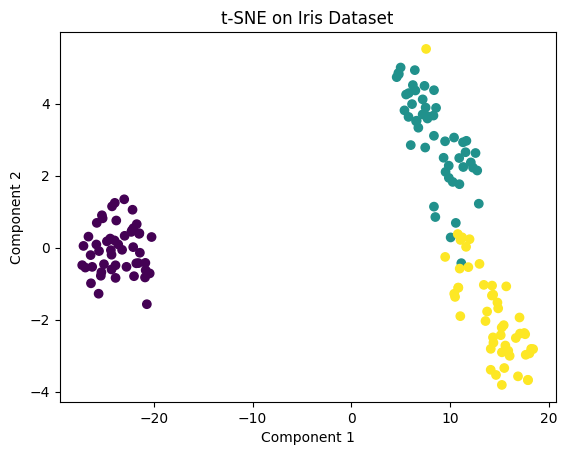

In [8]:
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data  #here the dimensions are initially 4.
labels = iris.target

tsne = TSNE(n_components=2, random_state=42)   #n_components=2 means reducing the dimensions from 4 to 2.
X_reduced = tsne.fit_transform(X) 

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels)
plt.title("t-SNE on Iris Dataset")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

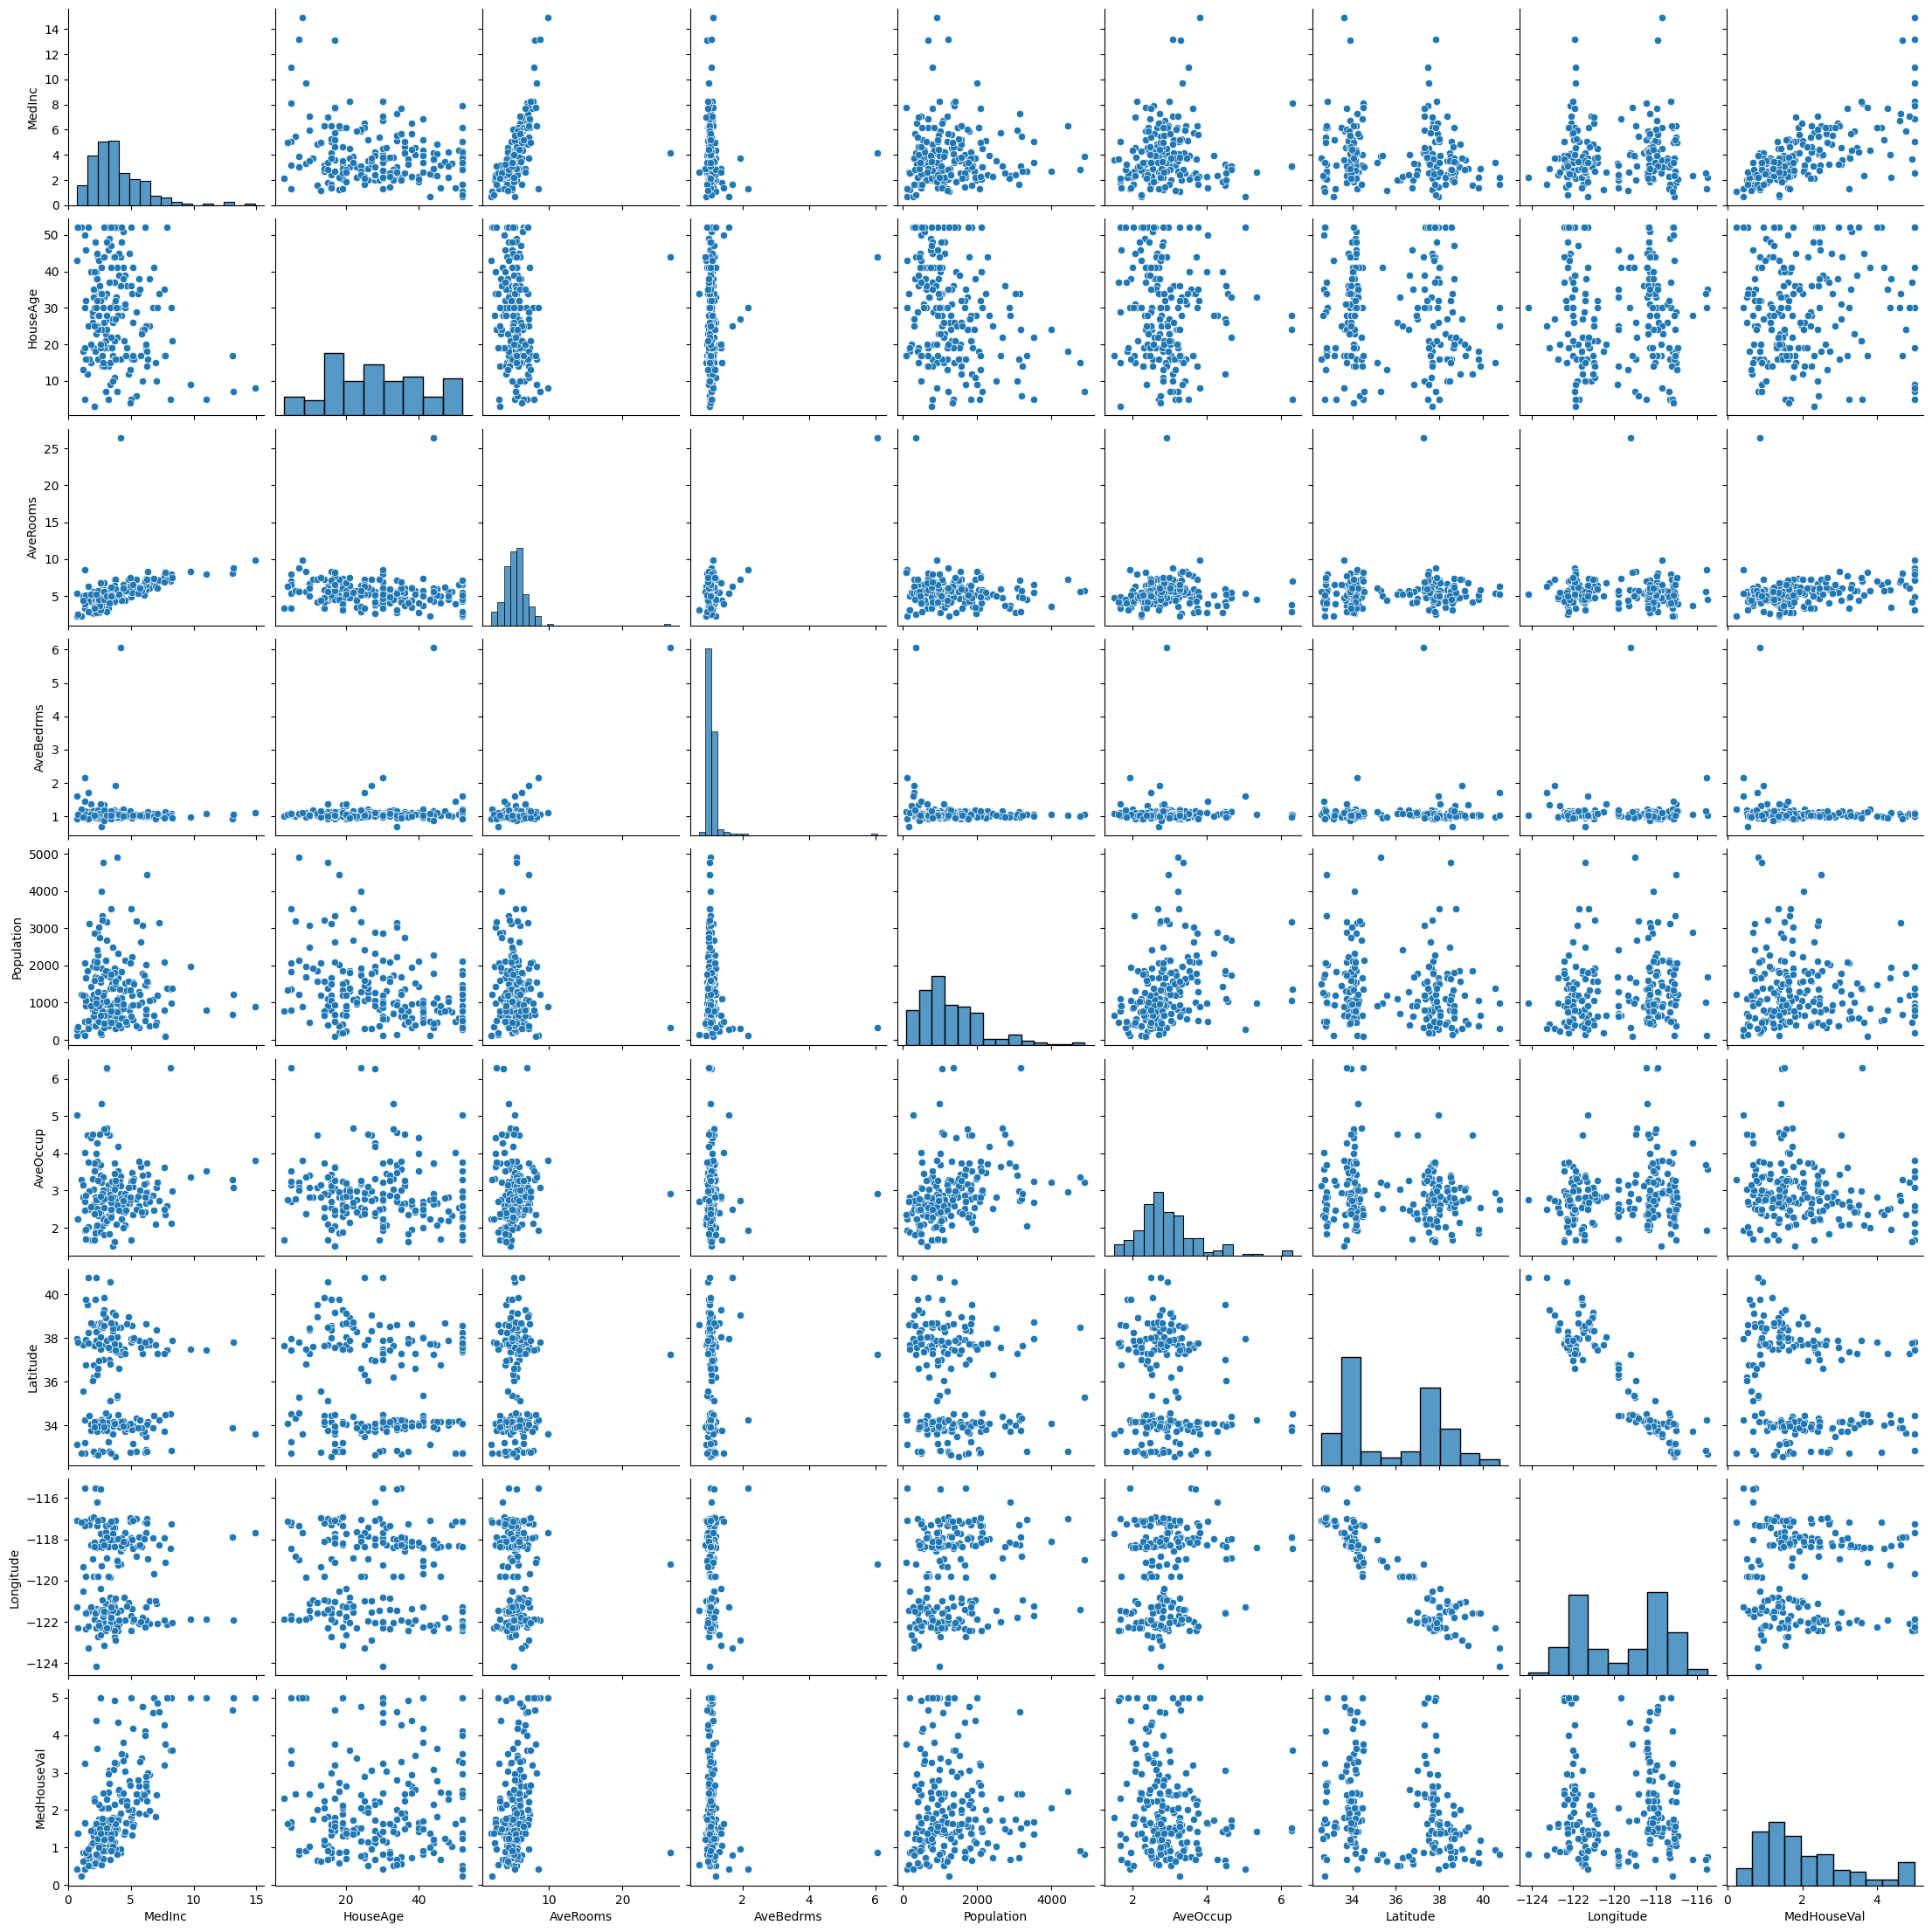

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame

sns.pairplot(df.sample(200))
plt.show()

Annual Average Temperature Trend:
Slope = 0.034312845261628325 °F/year
Per century = 3.4312845261628326 °F

January Average High Temperature Trend:
Slope = 0.026289969572412322 °F/year
Per century = 2.6289969572412324 °F



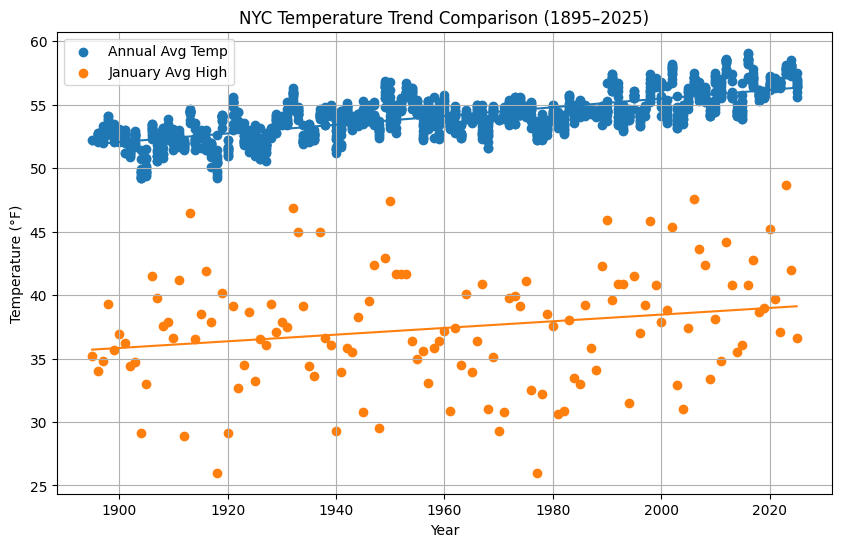

Annual averages are increasing faster than January temperatures.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Annual
annual_df = pd.read_csv("nyc_annual_temp.csv", skiprows=2)
annual_df = annual_df.dropna()
annual_df["Year"] = annual_df["Date"].astype(str).str[:4].astype(int)

X_ann = annual_df["Year"].values.reshape(-1, 1)
y_ann = annual_df["Value"].values

annual_model = LinearRegression()
annual_model.fit(X_ann, y_ann)

annual_slope = annual_model.coef_[0]
annual_intercept = annual_model.intercept_


# January
jan_df = pd.read_csv("nyc_january_high.csv", skiprows=2)
jan_df = jan_df.dropna()
jan_df["Year"] = jan_df["Date"].astype(str).str[:4].astype(int)

X_jan = jan_df["Year"].values.reshape(-1, 1)
y_jan = jan_df["Value"].values

jan_model = LinearRegression()
jan_model.fit(X_jan, y_jan)

jan_slope = jan_model.coef_[0]
jan_intercept = jan_model.intercept_


print("Annual Average Temperature Trend:")
print("Slope =", annual_slope, "°F/year")
print("Per century =", annual_slope * 100, "°F\n")

print("January Average High Temperature Trend:")
print("Slope =", jan_slope, "°F/year")
print("Per century =", jan_slope * 100, "°F\n")


plt.figure(figsize=(10,6))
plt.scatter(annual_df["Year"], annual_df["Value"], label="Annual Avg Temp")
plt.plot(annual_df["Year"], annual_model.predict(X_ann))

plt.scatter(jan_df["Year"], jan_df["Value"], label="January Avg High")
plt.plot(jan_df["Year"], jan_model.predict(X_jan))

plt.title("NYC Temperature Trend Comparison (1895–2025)")
plt.xlabel("Year")
plt.ylabel("Temperature (°F)")
plt.legend()
plt.grid(True)
plt.show()


if jan_slope > annual_slope:
    print("January temperatures are increasing faster than annual averages.")
else:
    print("Annual averages are increasing faster than January temperatures.")

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Prediction Accuracy:", accuracy)

Prediction Accuracy: 1.0


In [6]:
import math

points = {
    "A": ((2.0, 3.0), 0),
    "B": ((1.0, 1.0), 0),
    "C": ((4.0, 4.0), 1),
    "D": ((5.0, 2.0), 1),
}

P = (3.0, 3.0)
distances = []

for coord, label in points.values():
    dist = math.sqrt((coord[0]-P[0])**2 + (coord[1]-P[1])**2)
    distances.append((dist, label))

distances.sort()
k = 3
nearest = distances[:k]
classification = round(sum(label for _, label in nearest)/k)

print("Class of P:", classification)

Class of P: 1


In [7]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
#Input Features :-
X = np.array([
    [85,90,88],
    [70,75,80],
    [60,65,70],
    [50,55,58],
    [95,92,96],
    [45,50,48]
])
#Output Labels :-
y = np.array(["Pass","Pass","Fail","Fail","Pass","Fail"])

model = KNeighborsClassifier(n_neighbors=3)   #n_neighbors = 3 means look for 3 nearest neighbors.
model.fit(X, y)  #Train the model.
prediction = model.predict([[72,78,75]])   #predict() will return the ans in array.

print("Prediction:", prediction[0])

Prediction: Pass


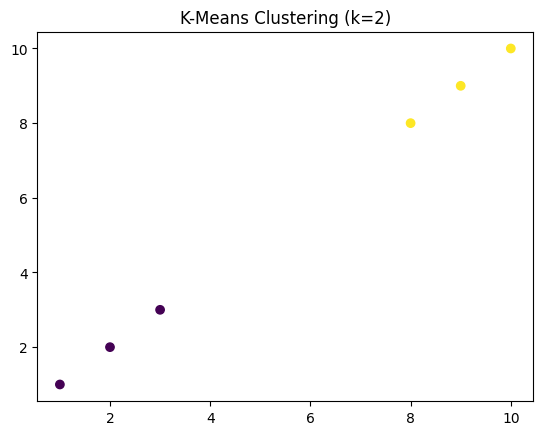

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X = np.array([(1,1),(2,2),(3,3),(8,8),(9,9),(10,10)])

model = KMeans(n_clusters=2, random_state=42)
labels = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("K-Means Clustering (k=2)")
plt.show()

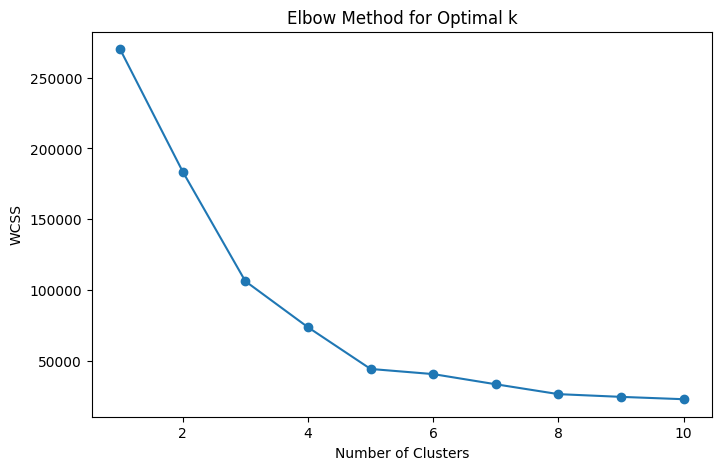

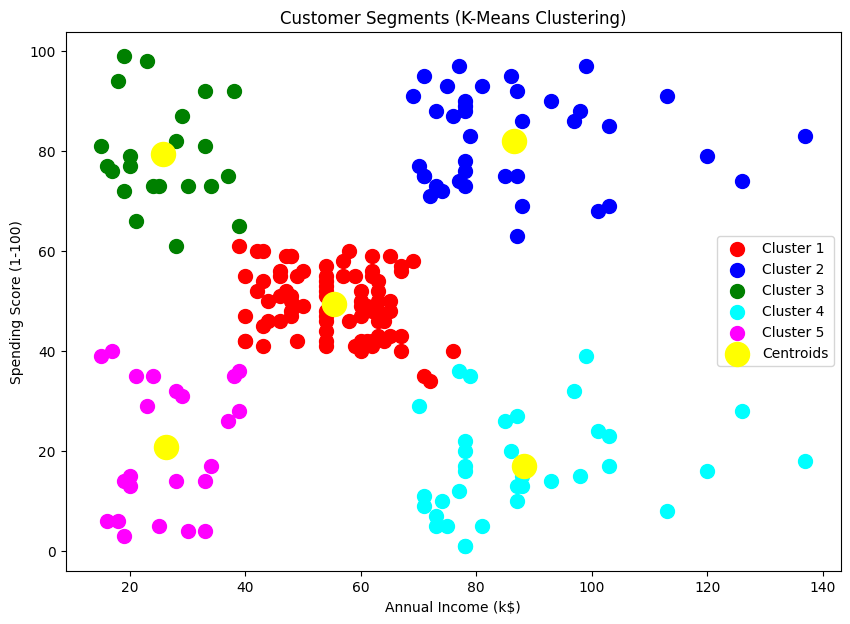

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

data = pd.read_csv("Mall_Customers.csv")
X = data.iloc[:, [3, 4]].values  

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(10,7))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=100, c='cyan', label='Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=100, c='magenta', label='Cluster 5')

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], 
            s=300, c='yellow', label='Centroids')

plt.title("Customer Segments (K-Means Clustering)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()